In [303]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
%matplotlib inline

In [304]:
df = pd.read_csv('/content/Train_dataset.csv')
df_test = pd.read_csv('/content/Test_dataset.csv')

In [305]:
df

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult
...,...,...,...,...,...,...,...,...,...
1961,83711.0,2.0,2.0,33.5,100.0,2.0,73.0,6.53,Adult
1962,83712.0,1.0,2.0,30.0,93.0,2.0,208.0,13.02,Adult
1963,83713.0,1.0,2.0,23.7,103.0,2.0,124.0,21.41,Adult
1964,83718.0,2.0,2.0,27.4,90.0,2.0,108.0,4.99,Adult


In [306]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1966 entries, 0 to 1965
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEQN       1954 non-null   float64
 1   RIAGENDR   1948 non-null   float64
 2   PAQ605     1953 non-null   float64
 3   BMXBMI     1948 non-null   float64
 4   LBXGLU     1953 non-null   float64
 5   DIQ010     1948 non-null   float64
 6   LBXGLT     1955 non-null   float64
 7   LBXIN      1957 non-null   float64
 8   age_group  1952 non-null   object 
dtypes: float64(8), object(1)
memory usage: 138.4+ KB


In [307]:
df.drop('SEQN', inplace=True, axis =1 )

In [308]:
df

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult
...,...,...,...,...,...,...,...,...
1961,2.0,2.0,33.5,100.0,2.0,73.0,6.53,Adult
1962,1.0,2.0,30.0,93.0,2.0,208.0,13.02,Adult
1963,1.0,2.0,23.7,103.0,2.0,124.0,21.41,Adult
1964,2.0,2.0,27.4,90.0,2.0,108.0,4.99,Adult


In [309]:
df_encoded = df.copy()

In [310]:
df_encoded.head()

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


In [311]:
df_encoded.isnull().sum()

,0
RIAGENDR,18
PAQ605,13
BMXBMI,18
LBXGLU,13
DIQ010,18
LBXGLT,11
LBXIN,9
age_group,14


In [312]:
df_encoded.columns

Index(['RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN',
       'age_group'],
      dtype='object')

In [313]:
df_encoded['RIAGENDR'] = df_encoded['RIAGENDR'].fillna(
    df_encoded['RIAGENDR'].mode()[0]
)

In [314]:
df_encoded['PAQ605'].unique()

array([ 2.,  1., nan,  7.])

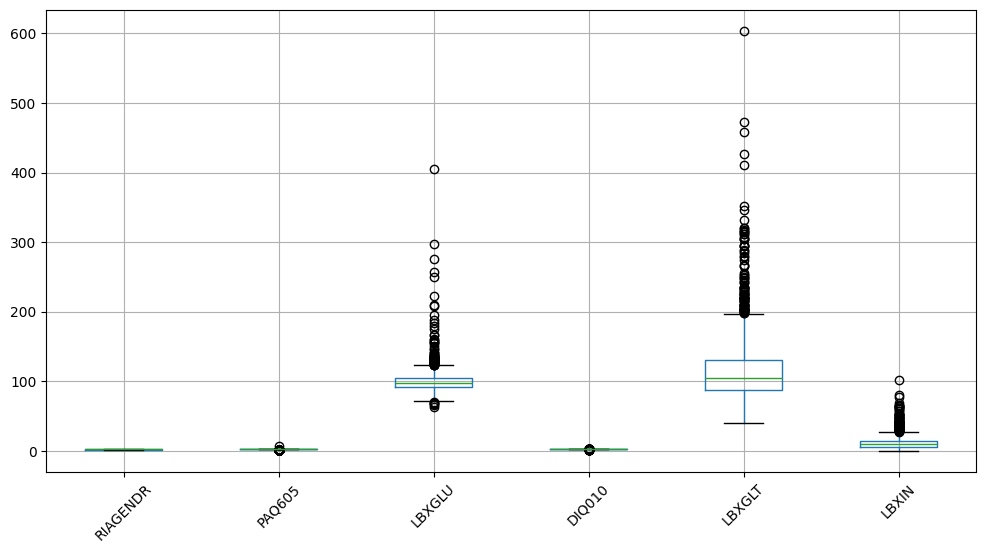

In [315]:
features = ['RIAGENDR', 'PAQ605', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN']

plt.figure(figsize=(12,6))
df_encoded[features].boxplot()
plt.xticks(rotation=45)
plt.show()

In [316]:
df_encoded['PAQ605'].value_counts()
df_encoded['PAQ605'] = df_encoded['PAQ605'].fillna(7)
df_encoded['PAQ605'].value_counts()

,count
PAQ605,
2.0,1606
1.0,346
7.0,14


In [317]:
df_encoded['BMXBMI'].value_counts()

,count
BMXBMI,
23.9,24
23.7,20
27.4,19
27.8,17
21.3,17
...,...
41.2,1
46.3,1
41.5,1


In [318]:
df_encoded['BMXBMI'].isnull().sum()

np.int64(18)

In [319]:
df_encoded['BMXBMI'] = df_encoded['BMXBMI'].fillna(df_encoded['BMXBMI'].median())

In [320]:
bmi_cols = [col for col in df_encoded.columns if col.startswith('BMI_Category_')]

df_encoded.drop(columns=bmi_cols, inplace=True)

In [321]:
df_encoded.head()

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


In [322]:
df_encoded['age_group'] = df_encoded['age_group'].map({
    'Adult': 0,
    'Senior': 1
})

In [323]:
df_encoded.isnull().sum()

,0
RIAGENDR,0
PAQ605,0
BMXBMI,0
LBXGLU,13
DIQ010,18
LBXGLT,11
LBXIN,9
age_group,14


In [324]:
import pandas as pd

bins = [0, 18.5, 25, 30, 35, 40, float('inf')]

labels = [
    'Underweight',
    'Normal',
    'Overweight',
    'Obesity_I',
    'Obesity_II',
    'Obesity_III'
]

df_encoded['BMI_Category'] = pd.cut(
    df_encoded['BMXBMI'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [325]:
df_encoded['LBXGLU'].value_counts()

,count
LBXGLU,
96.0,107
94.0,102
99.0,92
100.0,85
95.0,83
...,...
69.0,1
67.0,1
160.0,1


In [326]:
df_encoded[['LBXGLU', 'LBXGLT', 'LBXIN']].describe()

,LBXGLU,LBXGLT,LBXIN
count,1953.000000,1955.000000,1957.000000
mean,99.491039,115.150384,11.862892
std,16.774665,46.271615,9.756713
min,63.000000,40.000000,0.140000
25%,91.000000,87.000000,5.800000
50%,97.000000,105.000000,9.030000
75%,104.000000,131.000000,14.480000
max,405.000000,604.000000,102.290000


In [327]:
df_encoded.columns

Index(['RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN',
       'age_group', 'BMI_Category'],
      dtype='object')

In [328]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['BMI_Category'],
    prefix='BMI_Category',
    dtype=int
)

In [329]:
df_encoded.head()

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group,BMI_Category_Underweight,BMI_Category_Normal,BMI_Category_Overweight,BMI_Category_Obesity_I,BMI_Category_Obesity_II,BMI_Category_Obesity_III
0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,0.0,0,0,0,0,1,0
1,2.0,2.0,20.3,89.0,2.0,80.0,3.85,0.0,0,1,0,0,0,0
2,1.0,2.0,23.2,89.0,2.0,68.0,6.14,0.0,0,1,0,0,0,0
3,1.0,2.0,28.9,104.0,NaN,84.0,16.15,0.0,0,0,1,0,0,0
4,2.0,1.0,35.9,103.0,2.0,81.0,10.92,0.0,0,0,0,0,1,0


In [330]:
df_encoded['RIAGENDR'] = df_encoded['RIAGENDR'].map({1: 0, 2: 1})

In [331]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['PAQ605'],
    dtype=int
)

In [332]:
df_encoded['DIQ010'].value_counts()

,count
DIQ010,
2.0,1879
3.0,50
1.0,19


In [333]:
df_encoded = pd.get_dummies(
    df_encoded,
    columns=['DIQ010'],
    prefix='DIQ010',
    dtype=int
)

In [334]:
df_encoded.isnull().sum()

,0
RIAGENDR,0
BMXBMI,0
LBXGLU,13
LBXGLT,11
LBXIN,9
age_group,14
BMI_Category_Underweight,0
BMI_Category_Normal,0
BMI_Category_Overweight,0
BMI_Category_Obesity_I,0


In [335]:
df_encoded.dropna(subset=['age_group'], inplace=True)

In [336]:
num_cols = ['LBXGLU', 'LBXGLT', 'LBXIN']

for col in num_cols:
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())

In [337]:
df_encoded.isnull().sum()

,0
RIAGENDR,0
BMXBMI,0
LBXGLU,0
LBXGLT,0
LBXIN,0
age_group,0
BMI_Category_Underweight,0
BMI_Category_Normal,0
BMI_Category_Overweight,0
BMI_Category_Obesity_I,0


In [346]:
num_cols = ['BMXBMI', 'LBXGLU', 'LBXGLT', 'LBXIN']

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

In [347]:
x  = df_encoded.drop('age_group', axis=1)
y = df_encoded['age_group']

In [409]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight= 3.0
    ),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(x, y)

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200], 'subsample': [0.8, 1.0]},
             scoring='f1')

In [410]:
print(grid.best_params_)
print(grid.best_score_)

{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
0.4030543306726185


In [411]:
df_test_encoded = df_test.copy()

In [412]:
df_test_encoded.isnull().sum()

,0
SEQN,2
RIAGENDR,2
PAQ605,1
BMXBMI,1
LBXGLU,1
DIQ010,1
LBXGLT,2
LBXIN,1


In [413]:
# Mode values from the training data
df_test_encoded['RIAGENDR'] = df_test_encoded['RIAGENDR'].fillna(2)
df_test_encoded['PAQ605'] = df_test_encoded['PAQ605'].fillna(7)
df_test_encoded['DIQ010'] = df_test_encoded['DIQ010'].fillna(2)
# Numerical columns
num_cols = ['BMXBMI', 'LBXGLU', 'LBXGLT', 'LBXIN']

for col in num_cols:
    df_test_encoded[col] = df_test_encoded[col].fillna(
        df_encoded[col].median()
    )

In [414]:
print(df_test_encoded.isnull().sum())

SEQN        2
RIAGENDR    0
PAQ605      0
BMXBMI      0
LBXGLU      0
DIQ010      0
LBXGLT      0
LBXIN       0
dtype: int64


In [415]:
df_test_encoded.drop('SEQN', inplace=True, axis =1 )

In [416]:
bins = [0, 18.5, 25, 30, 35, 40, float('inf')]

labels = [
    'Underweight',
    'Normal',
    'Overweight',
    'Obesity_I',
    'Obesity_II',
    'Obesity_III'
]

df_test_encoded['BMI_Category'] = pd.cut(
    df_test_encoded['BMXBMI'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [417]:
df_test_encoded = pd.get_dummies(
    df_test_encoded,
    columns=['BMI_Category', 'PAQ605', 'DIQ010'],
    prefix=['BMI_Category', 'PAQ605', 'DIQ010'],
    dtype=int
)

In [418]:
print(df_test_encoded.columns)

Index(['RIAGENDR', 'BMXBMI', 'LBXGLU', 'LBXGLT', 'LBXIN',
       'BMI_Category_Underweight', 'BMI_Category_Normal',
       'BMI_Category_Overweight', 'BMI_Category_Obesity_I',
       'BMI_Category_Obesity_II', 'BMI_Category_Obesity_III', 'PAQ605_1.0',
       'PAQ605_2.0', 'PAQ605_7.0', 'DIQ010_1.0', 'DIQ010_2.0', 'DIQ010_3.0'],
      dtype='object')


In [419]:
print(df_test_encoded.columns.equals(x.columns))

True


In [420]:
num_cols = ['BMXBMI', 'LBXGLU', 'LBXGLT', 'LBXIN']

df_test_encoded[num_cols] = scaler.transform(
    df_test_encoded[num_cols]
)

In [421]:
predictions = grid.predict(df_test_encoded)

In [422]:
import numpy as np

print(np.unique(predictions, return_counts=True))

(array([0, 1]), array([258,  54]))


In [435]:
submission = pd.DataFrame({
    "age_group": predictions.astype(int)
})

submission.to_csv("submission.csv", index=False)

print(submission.head())
print(submission.shape)

   age_group
0          0
1          1
2          1
3          0
4          0
(312, 1)
